<a href="https://colab.research.google.com/github/shahalam1111/Urban-Tree-Canopy-Analysis-/blob/main/Urban_Canopy_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importing necessary libraries
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import matplotlib.pyplot as plt

In [2]:
# Load the neighborhood polygons
gdf = gpd.read_file('2020_Neighborhood_Tabulation_Areas_(NTAs)_20260610.csv')


In [3]:
# Select a specific neighborhood in Manhattan
gdf_ngh = gdf[gdf.BoroName == 'Manhattan'].head(1)

In [4]:
# Load the tree census data and create a GeoDataFrame
tdf = pd.read_csv('2015_Street_Tree_Census_-_Tree_Data_20260610.csv', nrows=10000)
geometry = [Point(xy) for xy in zip(tdf['longitude'], tdf['latitude'])]
tdf = gpd.GeoDataFrame(tdf, geometry=geometry)[['tree_id', 'stump_diam', 'status', 'health', 'geometry']]
tdf.crs = 4326

In [5]:
# Transform the GeoDataFrames to the local CRS of New York City (EPSG:2263)
import geopandas as gpd
from shapely import wkt

# Ensure gdf_ngh is a GeoDataFrame if it's not already
# Assuming 'the_geom' contains WKT strings and original CRS is EPSG:4326
if not isinstance(gdf_ngh, gpd.GeoDataFrame):
    gdf_ngh['geometry'] = gdf_ngh['the_geom'].apply(wkt.loads)
    gdf_ngh = gpd.GeoDataFrame(gdf_ngh, geometry='geometry', crs='EPSG:4326')

gdf_ngh_local = gdf_ngh.to_crs(2263)
tdf_local = tdf.to_crs(2263)


In [6]:
# Define a list of distance values for buffering
distances = [10, 1000, 10000, 25000, 50000, 75000]


Distance: 10 feet
Tree count: 18

Distance: 1000 feet
Tree count: 36

Distance: 10000 feet
Tree count: 824

Distance: 25000 feet
Tree count: 3165

Distance: 50000 feet
Tree count: 7232

Distance: 75000 feet
Tree count: 9676



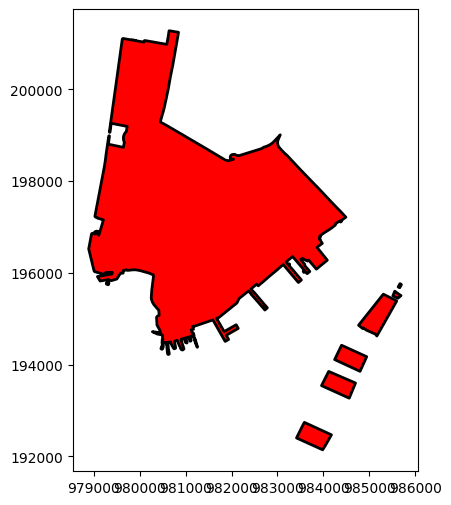

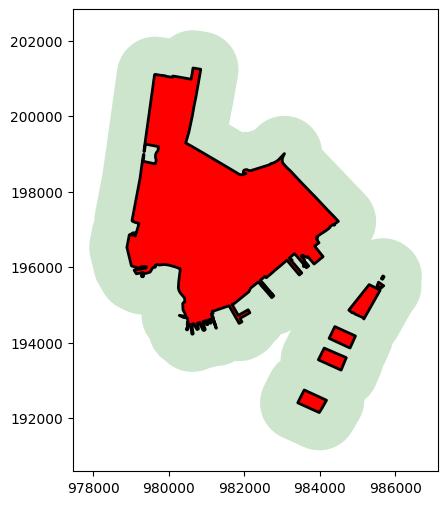

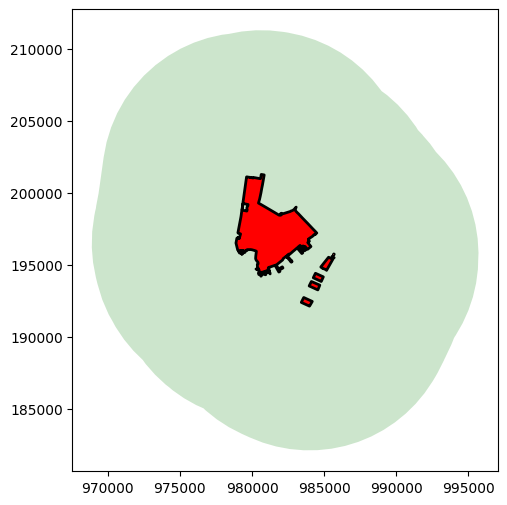

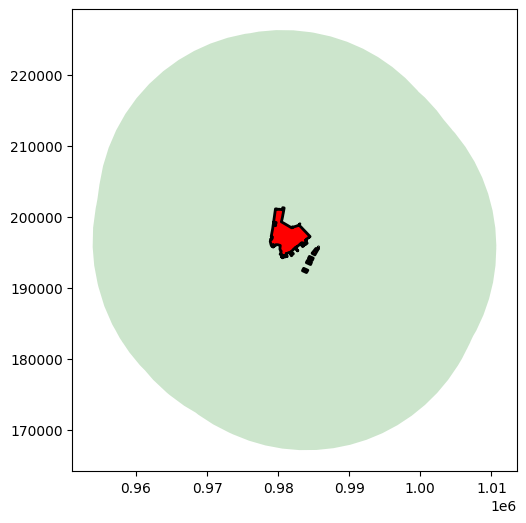

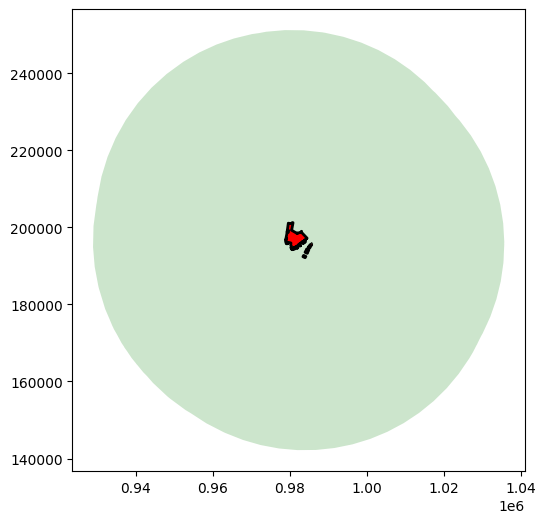

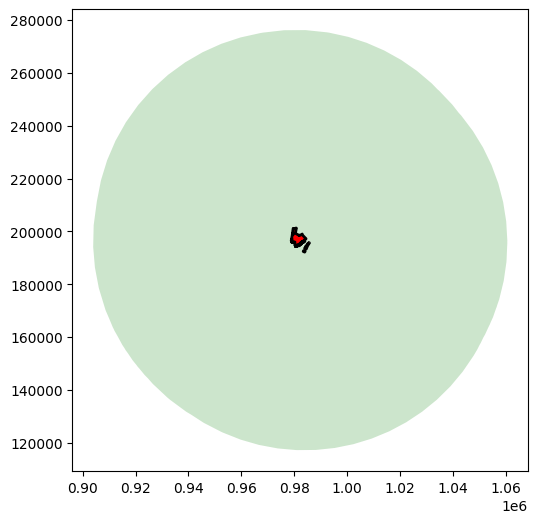

In [7]:
# Iterate over each distance, create buffers, and count trees within the buffer zone
for distance in distances:
    gdf_ngh_local_buffered = gdf_ngh_local.copy()
    gdf_ngh_local_buffered['geometry'] = gdf_ngh_local_buffered['geometry'].buffer(distance)
    gdf_joined = gpd.overlay(tdf_local, gdf_ngh_local_buffered, how='intersection')

    f, ax = plt.subplots(1, 1, figsize=(6, 6))
    gdf_ngh_local_buffered.plot(color='green', ax=ax, alpha=0.2)
    gdf_ngh_local.plot(color='red', ax=ax, edgecolor='k', linewidth=2)

    tree_count = len(gdf_joined['tree_id'].unique())
    print(f'Distance: {distance} feet')
    print(f'Tree count: {tree_count}')
    print()